## Processamento de Linguagem Natural - assignment 1

-----
Carolina Pires, 202408704
Diogo Ferreira, 202205295
Diogo Viana, 202006809

## 05. Models

In this notebook, we evaluate the impact of different text representations on classification performance. 
We compare response-only vs response + prompt input, as well as versions with and without punctuation, using the best-performing models identified in the baseline experiments.

### START DIOGO SECTION

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
results_df = pd.read_csv("../results/model_results.csv")

results_df.head()

,dataset,model,accuracy,precision,recall,f1_macro
0,resp_no_punct,Logistic Regression,0.791626,0.790617,0.791303,0.790883
1,comb_no_punct,Logistic Regression,0.791626,0.790668,0.790375,0.790512
2,comb_no_punct,SVM,0.791133,0.790111,0.790189,0.790149
3,resp_no_punct,SVM,0.790394,0.789381,0.789361,0.789371
4,comb_with_punct,Logistic Regression,0.789409,0.788385,0.788405,0.788395


In [3]:
results_df.sort_values(by="f1_macro", ascending=False)

,dataset,model,accuracy,precision,recall,f1_macro
0,resp_no_punct,Logistic Regression,0.791626,0.790617,0.791303,0.790883
1,comb_no_punct,Logistic Regression,0.791626,0.790668,0.790375,0.790512
2,comb_no_punct,SVM,0.791133,0.790111,0.790189,0.790149
3,resp_no_punct,SVM,0.790394,0.789381,0.789361,0.789371
4,comb_with_punct,Logistic Regression,0.789409,0.788385,0.788405,0.788395
5,resp_with_punct,Logistic Regression,0.788916,0.787898,0.788563,0.788157
6,comb_with_punct,SVM,0.787438,0.786391,0.786563,0.786473
7,resp_with_punct,SVM,0.784483,0.783433,0.783971,0.783656
8,resp_no_punct,Naive Bayes,0.776601,0.775539,0.775363,0.775447
9,resp_no_punct,Random Forest,0.770690,0.772004,0.773068,0.770603


In [4]:
best_per_dataset = results_df.loc[
    results_df.groupby("dataset")["f1_macro"].idxmax()
]

best_per_dataset

,dataset,model,accuracy,precision,recall,f1_macro
1,comb_no_punct,Logistic Regression,0.791626,0.790668,0.790375,0.790512
4,comb_with_punct,Logistic Regression,0.789409,0.788385,0.788405,0.788395
0,resp_no_punct,Logistic Regression,0.791626,0.790617,0.791303,0.790883
5,resp_with_punct,Logistic Regression,0.788916,0.787898,0.788563,0.788157


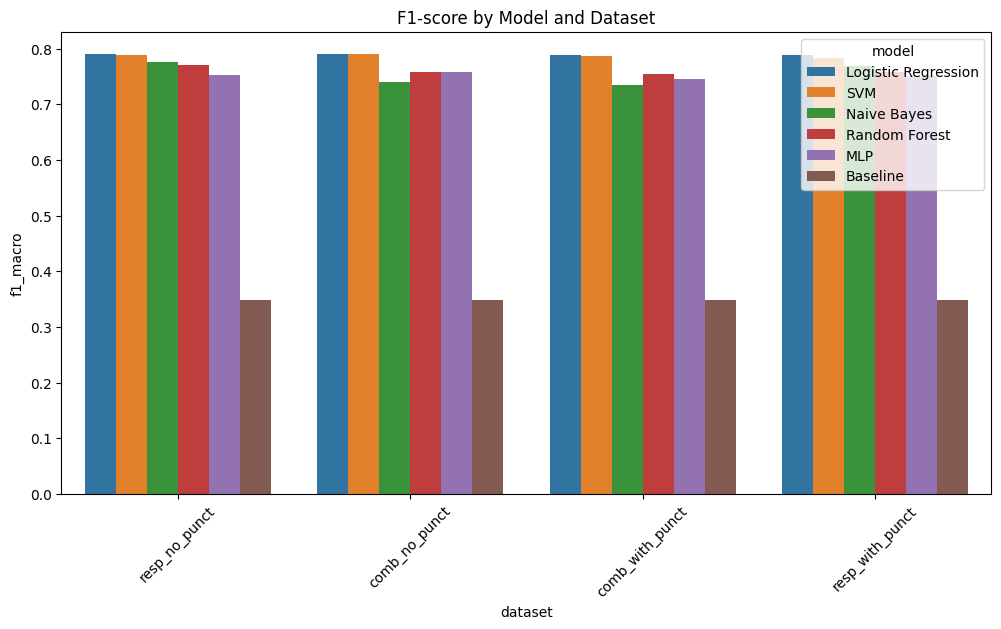

In [5]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=results_df,
    x="dataset",
    y="f1_macro",
    hue="model"
)

plt.title("F1-score by Model and Dataset")
plt.xticks(rotation=45)
plt.show()

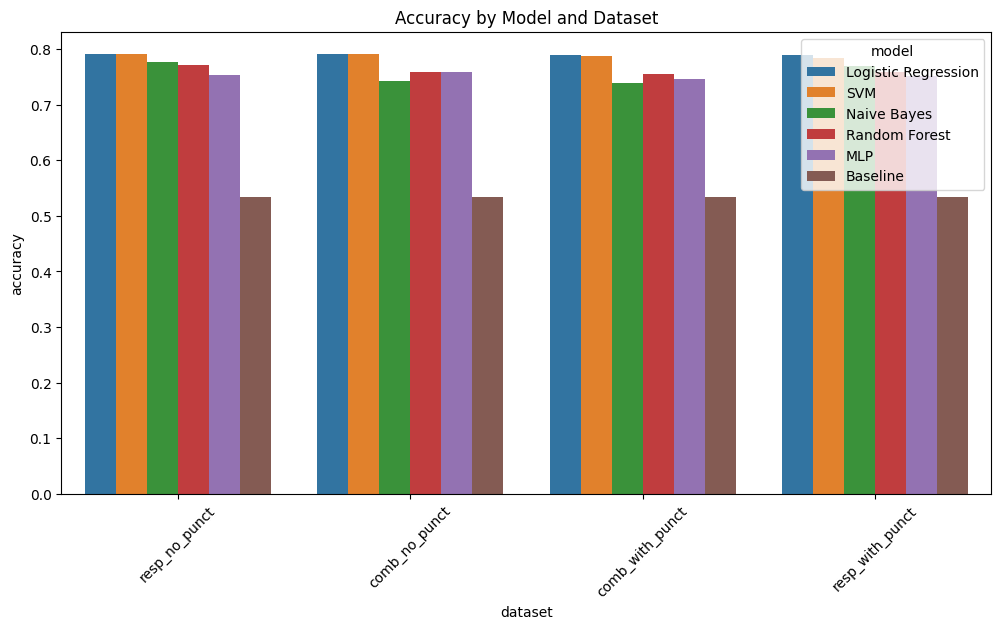

In [6]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=results_df,
    x="dataset",
    y="accuracy",
    hue="model"
)

plt.title("Accuracy by Model and Dataset")
plt.xticks(rotation=45)
plt.show()

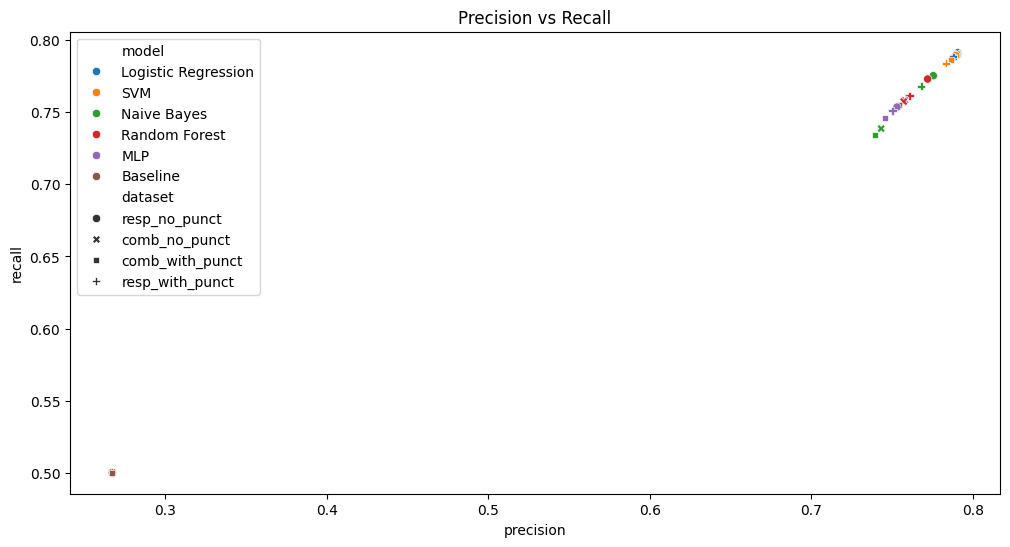

In [7]:
plt.figure(figsize=(12,6))

sns.scatterplot(
    data=results_df,
    x="precision",
    y="recall",
    hue="model",
    style="dataset"
)

plt.title("Precision vs Recall")
plt.show()

In [8]:
model_avg = results_df.groupby("model").mean(numeric_only=True)

model_avg.sort_values(by="f1_macro", ascending=False)

,accuracy,precision,recall,f1_macro
model,,,,
Logistic Regression,0.790394,0.789392,0.789662,0.789487
SVM,0.788362,0.787329,0.787521,0.787412
Random Forest,0.760653,0.761020,0.761757,0.760198
Naive Bayes,0.756897,0.756604,0.754145,0.754641
MLP,0.752771,0.751711,0.752350,0.751926
Baseline,0.534729,0.267365,0.500000,0.348419


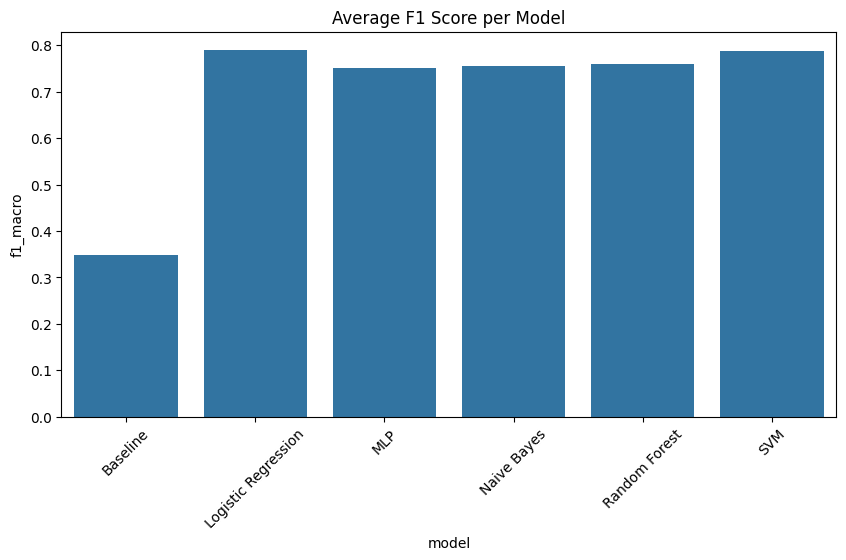

In [9]:
model_avg.reset_index(inplace=True)

plt.figure(figsize=(10,5))

sns.barplot(
    data=model_avg,
    x="model",
    y="f1_macro"
)

plt.title("Average F1 Score per Model")
plt.xticks(rotation=45)
plt.show()

In [10]:
dataset_avg = results_df.groupby("dataset").mean(numeric_only=True)

dataset_avg.sort_values(by="f1_macro", ascending=False)

,accuracy,precision,recall,f1_macro
dataset,,,,
resp_no_punct,0.736371,0.691328,0.730446,0.704665
resp_with_punct,0.731199,0.686311,0.725535,0.699568
comb_no_punct,0.729639,0.684429,0.722518,0.697365
comb_with_punct,0.725328,0.680213,0.718459,0.693125


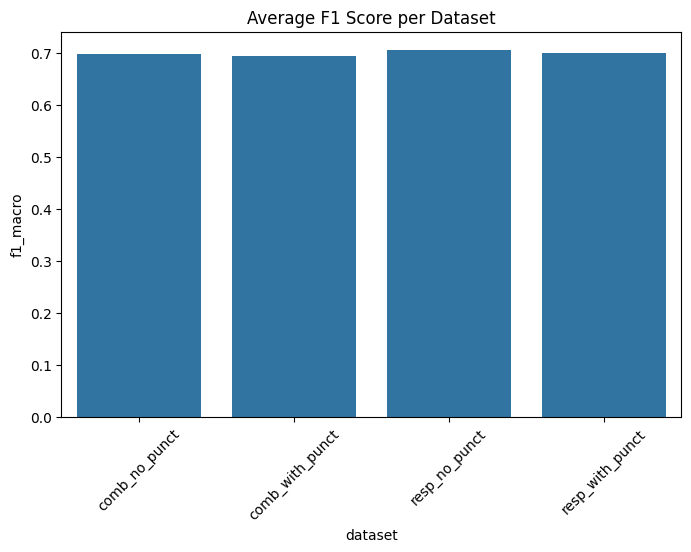

In [11]:
dataset_avg.reset_index(inplace=True)

plt.figure(figsize=(8,5))

sns.barplot(
    data=dataset_avg,
    x="dataset",
    y="f1_macro"
)

plt.title("Average F1 Score per Dataset")
plt.xticks(rotation=45)
plt.show()

In [12]:
pivot = results_df.pivot(index="model", columns="dataset", values="f1_macro")

pivot

dataset,comb_no_punct,comb_with_punct,resp_no_punct,resp_with_punct
model,,,,
Baseline,0.348419,0.348419,0.348419,0.348419
Logistic Regression,0.790512,0.788395,0.790883,0.788157
MLP,0.758152,0.745785,0.753267,0.750499
Naive Bayes,0.739630,0.735400,0.775447,0.768085
Random Forest,0.757325,0.754275,0.770603,0.758590
SVM,0.790149,0.786473,0.789371,0.783656


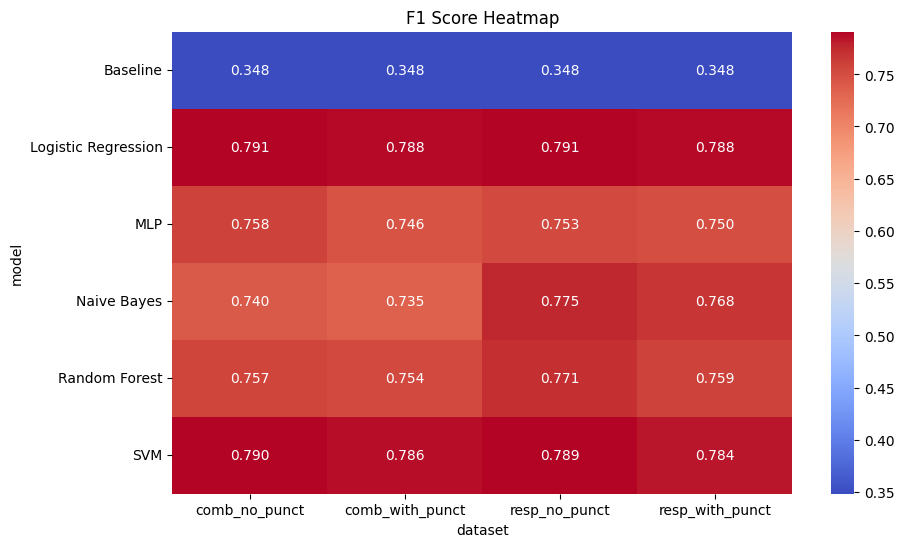

In [13]:
plt.figure(figsize=(10,6))

sns.heatmap(pivot, annot=True, fmt=".3f", cmap="coolwarm")

plt.title("F1 Score Heatmap")
plt.show()

In [14]:
best_model = model_avg.sort_values(by="f1_macro", ascending=False).iloc[0]

print("Best overall model:")
print(best_model)

Best overall model:
model        Logistic Regression
accuracy                0.790394
precision               0.789392
recall                  0.789662
f1_macro                0.789487
Name: 1, dtype: object


In [15]:
best_dataset = dataset_avg.sort_values(by="f1_macro", ascending=False).iloc[0]

print("Best dataset representation:")
print(best_dataset)

Best dataset representation:
dataset      resp_no_punct
accuracy          0.736371
precision         0.691328
recall            0.730446
f1_macro          0.704665
Name: 2, dtype: object


### END DIOGO SECTION

In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

### Loading the Dataset

In [9]:
DATA_PATH = "../data/processed/"

datasets = {
    "resp_no_punct": pd.read_csv(DATA_PATH + "resp_no_punct_train.csv"),
    "resp_with_punct": pd.read_csv(DATA_PATH + "resp_with_punct_train.csv"),
    "comb_no_punct": pd.read_csv(DATA_PATH + "comb_no_punct_train.csv"),
    "comb_with_punct": pd.read_csv(DATA_PATH + "comb_with_punct_train.csv"),
}

TARGET_COL = "is_safe"

### Evaluation Function

In [10]:
def evaluate_model(name, y_true, y_pred):
    return {
        "model": name,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0)
    }

### Running Models Across Variants

In [11]:
def run_models_for_variant(df, text_col, ngram_range=(1,1)):
    
    X = df[text_col].fillna("")
    y = df[TARGET_COL]

    X_train, X_val, y_train, y_val = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )

    tfidf = TfidfVectorizer(
        max_features=5000,
        ngram_range=ngram_range
    )

    X_train_tfidf = tfidf.fit_transform(X_train)
    X_val_tfidf = tfidf.transform(X_val)

    results = []

    # Logistic Regression
    lr = LogisticRegression(max_iter=1000, random_state=42)
    lr.fit(X_train_tfidf, y_train)
    y_pred_lr = lr.predict(X_val_tfidf)
    results.append(evaluate_model(f"{text_col} | LR | {ngram_range}", y_val, y_pred_lr))

    # Linear SVM
    svm = LinearSVC(random_state=42)
    svm.fit(X_train_tfidf, y_train)
    y_pred_svm = svm.predict(X_val_tfidf)
    results.append(evaluate_model(f"{text_col} | SVM | {ngram_range}", y_val, y_pred_svm))

    return pd.DataFrame(results)

### Comparison Across Variants (Unigram TF-IDF)

In [ ]:
all_results = []

for name, df in datasets.items():
    res = run_models_for_variant(df, text_col=name, ngram_range=(1,1))
    all_results.append(res)

results_df = pd.concat(all_results, ignore_index=True)
results_df.sort_values("macro_f1", ascending=False)

,model,accuracy,precision,recall,f1,macro_f1
2,"resp_with_punct | LR | (1, 1)",0.790640,0.809078,0.796407,0.802693,0.789856
3,"resp_with_punct | SVM | (1, 1)",0.789409,0.805195,0.799632,0.802404,0.788494
0,"resp_no_punct | LR | (1, 1)",0.788177,0.807602,0.792722,0.800093,0.787422
6,"comb_with_punct | LR | (1, 1)",0.786946,0.797901,0.805620,0.801742,0.785753
7,"comb_with_punct | SVM | (1, 1)",0.785714,0.799908,0.799171,0.799539,0.784690
1,"resp_no_punct | SVM | (1, 1)",0.784975,0.804981,0.789037,0.796930,0.784228
5,"comb_no_punct | SVM | (1, 1)",0.783990,0.798432,0.797328,0.797880,0.782965
4,"comb_no_punct | LR | (1, 1)",0.783744,0.796696,0.799632,0.798161,0.782635


### Results Overview

In [13]:
results_df.round(4)

,model,accuracy,precision,recall,f1,macro_f1
0,"resp_no_punct | LR | (1, 1)",0.7882,0.8076,0.7927,0.8001,0.7874
1,"resp_no_punct | SVM | (1, 1)",0.7850,0.8050,0.7890,0.7969,0.7842
2,"resp_with_punct | LR | (1, 1)",0.7906,0.8091,0.7964,0.8027,0.7899
3,"resp_with_punct | SVM | (1, 1)",0.7894,0.8052,0.7996,0.8024,0.7885
4,"comb_no_punct | LR | (1, 1)",0.7837,0.7967,0.7996,0.7982,0.7826
5,"comb_no_punct | SVM | (1, 1)",0.7840,0.7984,0.7973,0.7979,0.7830
6,"comb_with_punct | LR | (1, 1)",0.7869,0.7979,0.8056,0.8017,0.7858
7,"comb_with_punct | SVM | (1, 1)",0.7857,0.7999,0.7992,0.7995,0.7847


### Selecting Top Variants

In [14]:
top_variants = (
    results_df
    .sort_values("macro_f1", ascending=False)
    .head(4)
)

top_variants

,model,accuracy,precision,recall,f1,macro_f1
2,"resp_with_punct | LR | (1, 1)",0.790640,0.809078,0.796407,0.802693,0.789856
3,"resp_with_punct | SVM | (1, 1)",0.789409,0.805195,0.799632,0.802404,0.788494
0,"resp_no_punct | LR | (1, 1)",0.788177,0.807602,0.792722,0.800093,0.787422
6,"comb_with_punct | LR | (1, 1)",0.786946,0.797901,0.805620,0.801742,0.785753


### Bigram Experiments (1,2)

In [17]:
best_variant_names = [
    "resp_no_punct",
    "resp_with_punct"
]

bigram_results = []

for variant in best_variant_names:
    res = run_models_for_variant(datasets[variant], variant, ngram_range=(1,2))
    bigram_results.append(res)

results_bigram = pd.concat(bigram_results, ignore_index=True)
results_bigram.sort_values("macro_f1", ascending=False)

,model,accuracy,precision,recall,f1,macro_f1
0,"resp_no_punct | LR | (1, 2)",0.789163,0.811464,0.789037,0.800093,0.788530
2,"resp_with_punct | LR | (1, 2)",0.788424,0.811195,0.787655,0.799252,0.787806
3,"resp_with_punct | SVM | (1, 2)",0.786946,0.801199,0.800092,0.800645,0.785935
1,"resp_no_punct | SVM | (1, 2)",0.780049,0.796382,0.790880,0.793621,0.779094


### Final Comparison

In [18]:
final_results = pd.concat([results_df, results_bigram], ignore_index=True)
final_results.sort_values("macro_f1", ascending=False)

,model,accuracy,precision,recall,f1,macro_f1
2,"resp_with_punct | LR | (1, 1)",0.790640,0.809078,0.796407,0.802693,0.789856
8,"resp_no_punct | LR | (1, 2)",0.789163,0.811464,0.789037,0.800093,0.788530
3,"resp_with_punct | SVM | (1, 1)",0.789409,0.805195,0.799632,0.802404,0.788494
10,"resp_with_punct | LR | (1, 2)",0.788424,0.811195,0.787655,0.799252,0.787806
0,"resp_no_punct | LR | (1, 1)",0.788177,0.807602,0.792722,0.800093,0.787422
11,"resp_with_punct | SVM | (1, 2)",0.786946,0.801199,0.800092,0.800645,0.785935
6,"comb_with_punct | LR | (1, 1)",0.786946,0.797901,0.805620,0.801742,0.785753
7,"comb_with_punct | SVM | (1, 1)",0.785714,0.799908,0.799171,0.799539,0.784690
1,"resp_no_punct | SVM | (1, 1)",0.784975,0.804981,0.789037,0.796930,0.784228
5,"comb_no_punct | SVM | (1, 1)",0.783990,0.798432,0.797328,0.797880,0.782965
